# Networks

> **Extra dependencies required**
>
> Network support depends on libraries that are **not** installed by
> default, e.g. `networkx`. You can install them alongside `modelskill`
> using the *networks* extra:
>
> ``` bash
> uv pip install modelskill[networks]
> ```
>
> or
>
> ``` bash
> uv add modelskill[networks]
> ```

A **Network** represents a 1D pipe or river network as a directed graph:
nodes hold timeseries data (e.g. water level at a junction) and edges
carry the topology and reach length between them. Break points along an
edge (e.g. cross-section chainages) are supported as observation
locations too.

The typical workflow is:

    Network  →  NetworkModelResult  →  match()  →  Comparer

## Building a Network

You can build a `Network` object by loading it from a supported network
format.

Currently, the only supported format is `mikeio.Res1D`.

### Res1D file

The quickest way to get a `Network` is from the path to a MIKE 1D result
file:

In [3]:
from modelskill.network import Network

network = Network.from_res1d(path_to_res1d)
network

<Network>
Edges: 118
Nodes: 259
Quantities: ['WaterLevel', 'Discharge']
Time: 1994-08-07 16:35:00 - 1994-08-07 18:35:00

or a `mikeio1d.Res1D` that has already been opened:

``` python
from mikeio1d import Res1D

res = Res1D(path_to_res1d)
network = Network.from_res1d(res)
```

A `Res1D` network contains multiple levels that are unified into a
generic network structure as depicted in the image below. The image
introduces concepts like *find*, *recall* and *boundary* which are
explained in the following sections.

<figure>
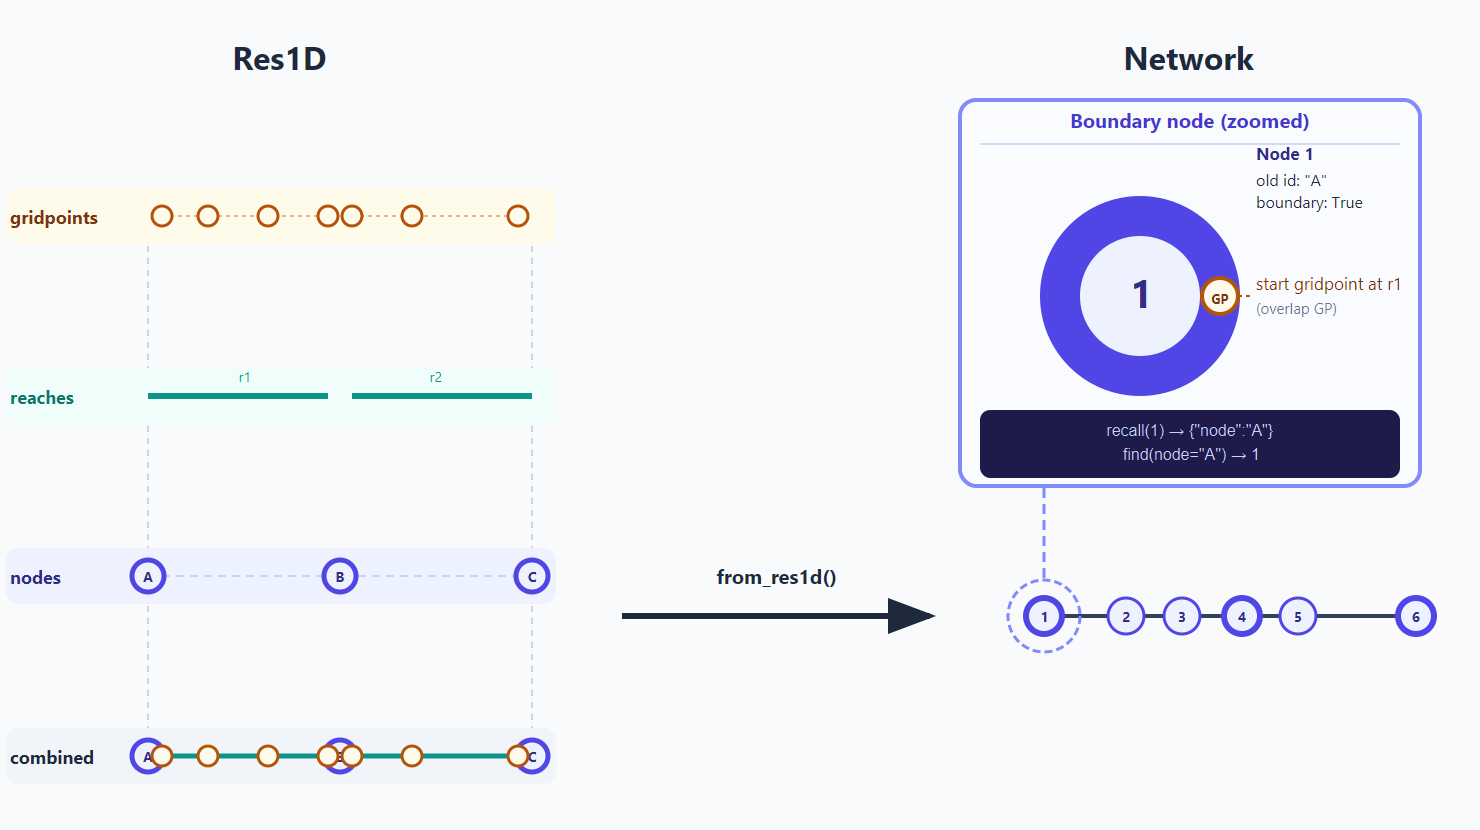
<figcaption aria-hidden="true">How a Res1D file maps to a Network
object. Reaches and nodes are re-indexed as integers; boundary nodes
expose <code>find()</code>/<code>recall()</code> round-trip
lookups.</figcaption>
</figure>

#### Selective loading

Large Res1D files can contain thousands of nodes and gridpoints. Loading
all of that data into memory is slow and may cause memory issues —
especially when you only need the timeseries at a handful of nodes where
observations exist.

`from_res1d` accepts two optional arguments to restrict what gets
loaded:

| Argument | Type | Effect |
|------------------------|------------------------|------------------------|
| `nodes` | `"all"` \| `str` \| `list[str]` | Control which nodes have timeseries data loaded. `"all"` (default) loads all nodes; `[]` skips all node data; a name or list loads only those nodes. |
| `reaches` | `"all"` \| `str` \| `list[str]` | Control which reaches have intermediate gridpoint data populated. `"all"` (default) loads everything; `[]` skips all gridpoints; a name or list of names loads only those reaches. |

> **Note**
>
> Selective loading only controls **which timeseries are held in
> memory**. The full network topology (nodes, edges, lengths) is always
> constructed so that `find()`, `recall()`, and graph algorithms still
> work on the complete network.

The most memory-efficient setup — useful when you only care about
specific junction nodes — is to pass the node IDs you need and skip all
intermediate gridpoints with `reaches=[]`:

In [4]:
network_subset = Network.from_res1d(
    path_to_res1d,
    nodes=["78", "46"],
    reaches=[],
)
network_subset

<Network>
Edges: 118
Nodes: 259
Quantities: ['WaterLevel']
Time: 1994-08-07 16:35:00 - 1994-08-07 18:35:00

If you also need gridpoint data along a particular reach, pass its name
(or a list of names):

In [5]:
network_subset = Network.from_res1d(
    path_to_res1d,
    nodes=["78", "46"],
    reaches=["94l1"],
)
network_subset

<Network>
Edges: 118
Nodes: 259
Quantities: ['WaterLevel', 'Discharge']
Time: 1994-08-07 16:35:00 - 1994-08-07 18:35:00

When only some nodes are loaded, `to_dataframe()` and `to_dataset()`
only contain columns for those nodes — the rest are graph-connected but
data-free:

In [6]:
network_subset.to_dataframe(sel="WaterLevel").head()

## Inspecting the Network

### Available quantities

In [7]:
network.quantities

['WaterLevel', 'Discharge']

### Underlying graph

The network exposes a `networkx.Graph` so you can use any NetworkX
algorithm or plotting function directly:

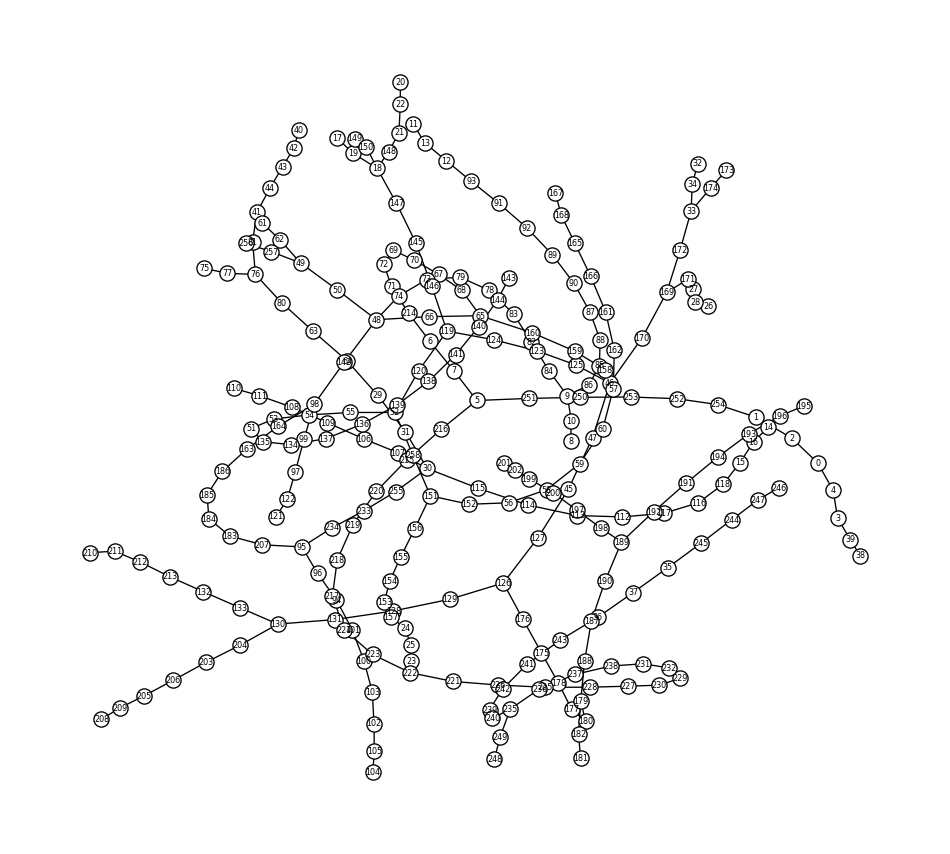

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 9), layout="tight")
nx.draw(network.graph, ax=ax, **plot_kwargs)
plt.show()

### Timeseries data

In [10]:
# Multi-index DataFrame: columns are (node, quantity)
network.to_dataframe().head()

5 rows × 259 columns

In [11]:
# Select a single quantity
network.to_dataframe(sel="WaterLevel").head()

5 rows × 130 columns

## Looking up node IDs

After construction, nodes are re-labelled as integers. Use `find()` to
go from original coordinates to the integer ID and `recall()` to go
back.

> **Tip**
>
> When creating `NodeObservation` objects for skill assessment you
> generally do **not** need to call `find()`. You can pass the original
> string ID or a `(edge, distance)` tuple directly as `node=`, and
> `NetworkModelResult` will resolve it for you during matching. See
> [Skill assessment workflow](#skill-assessment-workflow) for details.

In [12]:
# Look up a named node by its original id
node_id = network.find(node="117")
print(f"Node '117' → integer id {node_id}")

# Recover the original label
print(network.recall(node_id))

Node '117' → integer id 51
{'node': '117'}

In [13]:
# Look up a break point by reach + chainage
bp_id = network.find(edge="94l1", distance=21.285)
print(f"Break point (94l1, 21.285) → integer id {bp_id}")
print(network.recall(bp_id))

Break point (94l1, 21.285) → integer id 245
{'edge': '94l1', 'distance': 21.2852238539205}

In [14]:
# Node batch lookup
ids = network.find(node=["20", "113", "38"])
print(ids)

[76, 40, 15]

In [15]:
# Edge lookup
ids = network.find(edge="58l1", distance="start")
print(ids)
ids = network.find(edge="58l1", distance=[51.456, 77.185])
print(ids)
ids = network.find(edge="58l1", distance=["start", 77.185])
print(ids)

57
[159, 160]
[57, 160]

## Skill assessment workflow

### 1. Wrap the Network in a NetworkModelResult

In [16]:
import modelskill as ms
from modelskill.model.network import NetworkModelResult

mr = NetworkModelResult(network, name="MyModel", item="WaterLevel")
mr

<NetworkModelResult>: MyModel

### 2. Create NodeObservations and compute skill

`NodeObservation` accepts a file path directly; the observation name is
taken from the filename.

The `node=` argument can be specified in three ways, depending on what
information you have at hand.

#### Option A — integer node ID (direct)

Pass the integer ID assigned by the `Network`. This is the most explicit
form:

In [17]:
obs_1 = ms.NodeObservation(path_to_sensor_data_1, node=network.find(node="78"))
obs_2 = ms.NodeObservation(path_to_sensor_data_2, node=network.find(node="46"))

cc = ms.match(obs=[obs_1, obs_2], mod=mr)
cc.skill()

#### Option B — original string alias

Pass the original node identifier from the source format (e.g. the Res1D
node name) as a plain string. The `NetworkModelResult` resolves it to
the correct integer ID at match time, so you never need to call
`network.find()` yourself:

In [18]:
obs_1 = ms.NodeObservation(path_to_sensor_data_1, node="78")
obs_2 = ms.NodeObservation(path_to_sensor_data_2, node="46")

cc = ms.match(obs=[obs_1, obs_2], mod=mr)
cc.skill()

> **Note**
>
> Resolution happens inside `ms.match()`. If the string is not found in
> the network’s alias map a `ValueError` is raised with a clear message
> indicating which alias could not be resolved.

#### Option C — breakpoint by `(edge, distance)` tuple

When your observation sits at a chainage along a reach rather than at a
named junction node, pass a `(edge_id, distance)` tuple. The
`NetworkModelResult` looks up the corresponding breakpoint at match
time:

``` python
obs_bp = ms.NodeObservation(path_to_sensor_data_1, node=("94l1", 21.285))

cc = ms.match(obs=obs_bp, mod=mr)
cc.skill()
```

The tuple form is equivalent to calling
`network.find(edge="94l1", distance=21.285)` beforehand and is resolved
during matching.

> **Chainage tolerance**
>
> Breakpoint distances are matched with a tolerance of **1 × 10⁻³**
> (i.e. ±0.001 in whatever distance units the network uses). This means
> that small floating-point discrepancies between the distance you type
> and the value stored in the network are handled gracefully. If no
> breakpoint falls within that tolerance a `ValueError` is raised.

## Development

### Custom network formats

In case you have your network data in a format that is not included in
[Building a Network](#building-a-network), you can assemble a `Network`
object by subclassing the abstract base classes `NetworkNode` and
`NetworkEdge`.

`NetworkNode` requires three properties: `id`, `data`, and `boundary`.
`NetworkEdge` requires five: `id`, `start`, `end`, `length`, and
`breakpoints`.

The following is a simple implementation example:

``` python
import pandas as pd
import numpy as np
from typing import Any
from modelskill.network import NetworkNode, NetworkEdge, Network


class ExampleNode(NetworkNode):
    """Node backed by an in-memory DataFrame, e.g. model output."""

    def __init__(self, node_id: str, data: pd.DataFrame):
        self._id = node_id
        self._data = data

    @property
    def id(self) -> str:
        return self._id

    @property
    def data(self) -> pd.DataFrame:
        return self._data

    @property
    def boundary(self) -> dict[str, Any]:
        return {}


class ExampleEdge(NetworkEdge):
    """Edge connecting two nodes with a given length."""

    def __init__(
        self, edge_id: str, start: NetworkNode, end: NetworkNode, length: float,
        breakpoints: list | None = None,
    ):
        self._id = edge_id
        self._start = start
        self._end = end
        self._length = length
        self._breakpoints = breakpoints or []

    @property
    def id(self) -> str:
        return self._id

    @property
    def start(self) -> NetworkNode:
        return self._start

    @property
    def end(self) -> NetworkNode:
        return self._end

    @property
    def length(self) -> float:
        return self._length

    @property
    def breakpoints(self) -> list:
        return self._breakpoints
```

> **Tip**
>
> The three abstract properties that **every** `NetworkNode` subclass
> must implement are `id`, `data` and `boundary`. If `boundary` is not
> relevant for your use case, define the property to return an empty
> dictionary, as in the example above. Similarly, a `NetworkEdge` with
> no intermediate points can return an empty `breakpoints` list.

In [19]:
from modelskill.network import Network

# df1, df2 and df3 are DataFrame objects that are loaded in memory
node_s1 = ExampleNode("sensor_1", df1)
node_s2 = ExampleNode("sensor_2", df2)
node_s3 = ExampleNode("sensor_3", df3)

edge1 = ExampleEdge("r1", node_s1, node_s2, length=500.0)
edge2 = ExampleEdge("r2", node_s2, node_s3, length=300.0)

network = Network(edges=[edge1, edge2])
network

<Network>
Edges: 2
Nodes: 3
Quantities: ['WaterLevel']
Time: 1994-08-07 16:00:00 - 1994-08-07 18:59:00

### Adding break points along a reach

Break points represent intermediate chainage locations on a reach
(e.g. cross-sections). Subclass `EdgeBreakPoint` the same way —
implement `id` (a `(edge_id, distance)` tuple) and `data`:

``` python
from modelskill.network import EdgeBreakPoint


class ExampleBreakPoint(EdgeBreakPoint):
    def __init__(self, edge_id: str, distance: float, data: pd.DataFrame):
        self._id = (edge_id, distance)
        self._data = data

    @property
    def id(self):
        return self._id

    @property
    def data(self):
        return self._data


# df4 is a DataFrame object that has been loaded in memory
bp = ExampleBreakPoint("r1", 200.0, df4)
edge1 = ExampleEdge("r1", node_s1, node_s2, length=500.0, breakpoints=[bp])
edge2 = ExampleEdge("r2", node_s2, node_s3, length=300.0)
network = Network(edges=[edge1, edge2])
```

## See also

-   [API reference — NetworkModelResult](../api/NetworkModelResult.qmd)
-   [API reference — NodeObservation](../api/NodeObservation.qmd)